# Alocação de horários universitários: Guloso vs. VNS

Este notebook compara duas estratégias para alocar turmas (ou exames) em horários sem conflito:

- **Guloso por coloração de grafos**: ordena os eventos pelos de maior grau de conflito e usa a primeira cor disponível.
- **Busca em Vizinhança Variável (VNS)**: alterna perturbações de diferentes tamanhos com busca local.

Um vértice representa uma turma; uma aresta representa conflito por professor ou por grupo de alunos. Uma cor representa um horário. O objetivo primário é zerar conflitos e, em seguida, usar o menor número de horários possível.

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEMENTE = 42
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Instância sintética

Cada turma recebe um professor e de 1 a 3 grupos de alunos. Duas turmas são adjacentes se compartilham pelo menos um desses recursos. Em um caso real, substitua `gerar_instancia` por dados institucionais.

In [3]:
def gerar_instancia(n_turmas=120, n_professores=36, n_grupos=56, seed=42):
    gerador = np.random.default_rng(seed)
    turmas = pd.DataFrame({
        'turma': [f'T{indice:03d}' for indice in range(n_turmas)],
        'professor': gerador.integers(0, n_professores, size=n_turmas),
    })
    turmas['grupos'] = [
        tuple(sorted(gerador.choice(n_grupos, size=gerador.integers(1, 4), replace=False)))
        for _ in range(n_turmas)
    ]

    adjacencias = [set() for _ in range(n_turmas)]
    for i in range(n_turmas):
        for j in range(i + 1, n_turmas):
            mesmo_professor = turmas.loc[i, 'professor'] == turmas.loc[j, 'professor']
            grupos_em_comum = set(turmas.loc[i, 'grupos']) & set(turmas.loc[j, 'grupos'])
            if mesmo_professor or grupos_em_comum:
                adjacencias[i].add(j)
                adjacencias[j].add(i)
    return turmas, adjacencias

turmas, adjacencias = gerar_instancia(seed=SEMENTE)
n_arestas = sum(map(len, adjacencias)) // 2
print(f'{len(turmas)} turmas, {n_arestas} conflitos, grau médio: {2 * n_arestas / len(turmas):.1f}')
turmas.head()

120 turmas, 683 conflitos, grau médio: 11.4


,turma,professor,grupos
0,T000,3,"(36, 55)"
1,T001,27,"(4, 30, 42)"
2,T002,23,"(5, 30)"
3,T003,15,"(1, 16, 33)"
4,T004,15,"(11, 15, 22)"


## 2. Algoritmo guloso

A ordenação é decrescente pelo grau do vértice: as turmas mais restritivas são tratadas primeiro. Para cada turma, o método escolhe a menor cor ainda não usada por seus vizinhos já coloridos.

In [4]:
def coloracao_gulosa(adjacencias):
    n = len(adjacencias)
    ordem = sorted(range(n), key=lambda v: len(adjacencias[v]), reverse=True)
    cores = np.full(n, -1, dtype=int)

    for vertice in ordem:
        cores_vizinhas = {cores[vizinho] for vizinho in adjacencias[vertice] if cores[vizinho] >= 0}
        cor = 0
        while cor in cores_vizinhas:
            cor += 1
        cores[vertice] = cor
    return cores

def contar_conflitos(cores, adjacencias):
    return sum(
        cores[u] == cores[v]
        for u in range(len(adjacencias))
        for v in adjacencias[u] if v > u
    )

inicio = time.perf_counter()
solucao_gulosa = coloracao_gulosa(adjacencias)
tempo_guloso = time.perf_counter() - inicio
print(f'Horários: {solucao_gulosa.max() + 1} | Conflitos: {contar_conflitos(solucao_gulosa, adjacencias)} | Tempo: {tempo_guloso * 1e3:.3f} ms')

Horários: 10 | Conflitos: 0 | Tempo: 0.589 ms


## 3. Busca em Vizinhança Variável (VNS)

A VNS mantém uma única solução. Ela começa em uma alocação aleatória, aplica uma perturbação (*shaking*) em `k` turmas, melhora o resultado com busca local e aumenta `k` quando não encontra avanço. Ela usa o mesmo número máximo de horários do guloso.

In [5]:
def custo_solucao(individuo, adjacencias):
    conflitos = contar_conflitos(individuo, adjacencias)
    horarios_usados = len(np.unique(individuo))
    # Minimização: qualquer conflito é pior que usar uma cor adicional.
    return conflitos * (len(individuo) + 1) + horarios_usados

def delta_conflitos(cores, turma, nova_cor, adjacencias):
    cor_atual = cores[turma]
    antes = sum(cores[vizinho] == cor_atual for vizinho in adjacencias[turma])
    depois = sum(cores[vizinho] == nova_cor for vizinho in adjacencias[turma])
    return depois - antes

def busca_local(solucao, adjacencias, n_horarios, gerador, max_passos=120):
    atual = solucao.copy()
    # A avaliação incremental evita recomputar todas as arestas a cada troca.
    for _ in range(max_passos):
        melhor_movimento, melhor_delta = None, 0
        for turma in gerador.permutation(len(atual)):
            cor_original = atual[turma]
            for cor in range(n_horarios):
                if cor == cor_original:
                    continue
                delta = delta_conflitos(atual, turma, cor, adjacencias)
                if delta < melhor_delta:
                    melhor_movimento, melhor_delta = (turma, cor), delta
        if melhor_movimento is None:
            break
        atual[melhor_movimento[0]] = melhor_movimento[1]
    return atual

def executar_vns(adjacencias, n_horarios, seed=42, iteracoes=100, k_max=5):
    gerador = np.random.default_rng(seed)
    melhor = gerador.integers(0, n_horarios, size=len(adjacencias))
    melhor = busca_local(melhor, adjacencias, n_horarios, gerador)
    historico = [custo_solucao(melhor, adjacencias)]
    k = 1

    for _ in range(iteracoes):
        candidato = melhor.copy()
        turmas_perturbadas = gerador.choice(len(candidato), size=min(k, len(candidato)), replace=False)
        candidato[turmas_perturbadas] = gerador.integers(0, n_horarios, size=len(turmas_perturbadas))
        candidato = busca_local(candidato, adjacencias, n_horarios, gerador)
        if custo_solucao(candidato, adjacencias) < custo_solucao(melhor, adjacencias):
            melhor, k = candidato, 1
        else:
            k = 1 if k == k_max else k + 1
        historico.append(custo_solucao(melhor, adjacencias))
    return melhor, historico

n_horarios = solucao_gulosa.max() + 1
inicio = time.perf_counter()
solucao_vns, historico_vns = executar_vns(adjacencias, n_horarios=n_horarios, seed=SEMENTE)
tempo_vns = time.perf_counter() - inicio
print(f'Horários: {len(np.unique(solucao_vns))} | Conflitos: {contar_conflitos(solucao_vns, adjacencias)} | Tempo: {tempo_vns:.3f} s')

Horários: 10 | Conflitos: 0 | Tempo: 3.319 s


## 4. Resultado de uma instância

O gráfico mostra o melhor custo acumulado ao longo das iterações. A VNS é estocástica: experimente mudar `SEMENTE` e seus hiperparâmetros.

,algoritmo,horarios,conflitos,tempo_s
0,Guloso (grau),10,0,0.000589
1,VNS,10,0,3.318969


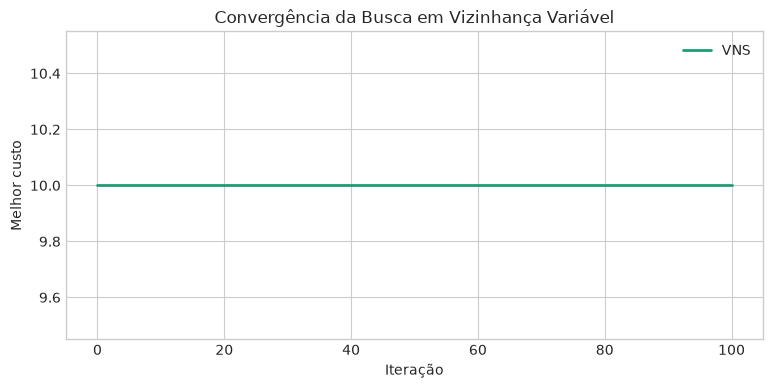

In [6]:
resumo = pd.DataFrame([
    {'algoritmo': 'Guloso (grau)', 'horarios': solucao_gulosa.max() + 1,
     'conflitos': contar_conflitos(solucao_gulosa, adjacencias), 'tempo_s': tempo_guloso},
    {'algoritmo': 'VNS', 'horarios': len(np.unique(solucao_vns)),
     'conflitos': contar_conflitos(solucao_vns, adjacencias), 'tempo_s': tempo_vns},
])
display(resumo.round({'tempo_s': 6}))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(historico_vns, color='#1b9e77', linewidth=2, label='VNS')
ax.set(title='Convergência da Busca em Vizinhança Variável', xlabel='Iteração', ylabel='Melhor custo')
ax.legend()
plt.show()

## 5. Experimento em diferentes tamanhos

O benchmark abaixo mede o guloso uma vez por instância e a VNS três vezes, reportando a mediana. Isto reduz o efeito de uma execução particularmente boa ou ruim da busca estocástica.

,turmas,algoritmo,tempo_s,conflitos,horarios
0,60,Guloso,0.000144,0,9
1,60,VNS (mediana),0.597345,0,9
2,100,Guloso,0.000256,0,8
3,100,VNS (mediana),0.937757,3,8
4,140,Guloso,0.000343,0,9
5,140,VNS (mediana),1.586817,1,9


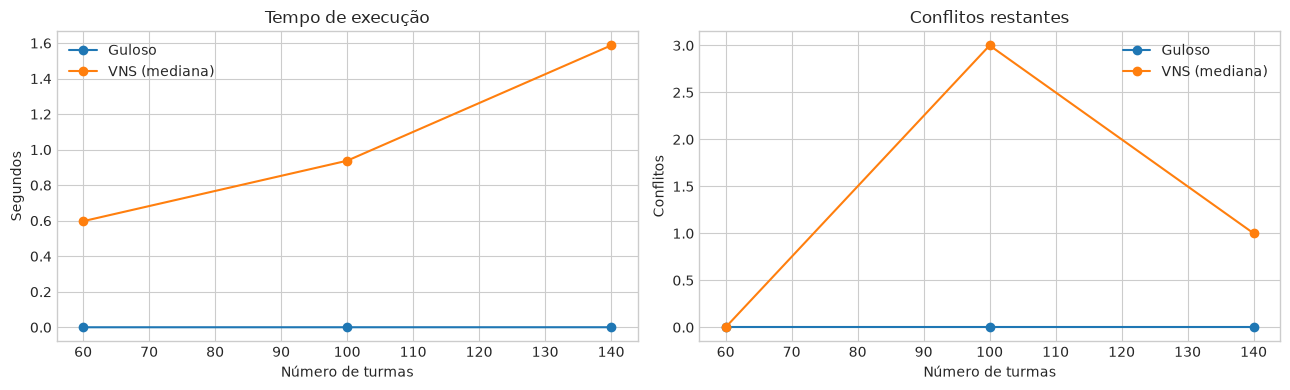

In [7]:
def benchmark(tamanhos=(60, 100, 140), repeticoes_vns=3, seed=42):
    linhas = []
    for tamanho in tamanhos:
        _, grafo = gerar_instancia(
            n_turmas=tamanho,
            n_professores=max(6, round(tamanho * 0.30)),
            n_grupos=max(10, round(tamanho * 0.47)),
            seed=seed + tamanho,
        )

        inicio = time.perf_counter()
        guloso = coloracao_gulosa(grafo)
        tempo = time.perf_counter() - inicio
        linhas.append({'turmas': tamanho, 'algoritmo': 'Guloso', 'tempo_s': tempo,
                       'conflitos': contar_conflitos(guloso, grafo), 'horarios': guloso.max() + 1})

        resultados_vns = []
        for rodada in range(repeticoes_vns):
            inicio = time.perf_counter()
            vns, _ = executar_vns(grafo, guloso.max() + 1, seed=seed + tamanho + rodada,
                                iteracoes=45, k_max=4)
            resultados_vns.append((time.perf_counter() - inicio, contar_conflitos(vns, grafo), len(np.unique(vns))))
        linhas.append({'turmas': tamanho, 'algoritmo': 'VNS (mediana)',
                       'tempo_s': np.median([r[0] for r in resultados_vns]),
                       'conflitos': int(np.median([r[1] for r in resultados_vns])),
                       'horarios': int(np.median([r[2] for r in resultados_vns]))})
    return pd.DataFrame(linhas)

resultados = benchmark()
display(resultados)

fig, eixos = plt.subplots(1, 2, figsize=(13, 4))
for nome, grupo in resultados.groupby('algoritmo'):
    eixos[0].plot(grupo['turmas'], grupo['tempo_s'], marker='o', label=nome)
    eixos[1].plot(grupo['turmas'], grupo['conflitos'], marker='o', label=nome)
eixos[0].set(title='Tempo de execução', xlabel='Número de turmas', ylabel='Segundos')
eixos[1].set(title='Conflitos restantes', xlabel='Número de turmas', ylabel='Conflitos')
for eixo in eixos:
    eixo.legend()
plt.tight_layout()
plt.show()

## Conclusões e extensões

Em geral, o guloso entrega uma grade viável quase instantaneamente, embora não garanta o mínimo global de horários. A VNS explora o espaço de soluções e pode escapar de ótimos locais ao variar o tamanho da perturbação, em troca de maior tempo de execução.

Para uma aplicação real, possíveis extensões são: capacidade de salas, indisponibilidade de professor, janelas de preferência, limites diários e uma função de custo multiobjetivo. Também vale testar mais estruturas de vizinhança e uma etapa de reparo de soluções inviáveis.

In [8]:
import time
_, g120 = gerar_instancia(seed=42)
t0 = time.perf_counter(); s = coloracao_gulosa(g120); tg = time.perf_counter() - t0
t0 = time.perf_counter(); v, _ = executar_vns(g120, s.max() + 1, seed=42); tv = time.perf_counter() - t0
print(f'Guloso: {tg:.6f} s | VNS: {tv:.6f} s | conflitos VNS: {contar_conflitos(v, g120)}')

Guloso: 0.000338 s | VNS: 3.028226 s | conflitos VNS: 0


In [11]:
# ===== Célula extra: verificações complementares (não altera as células anteriores) =====
import timeit

SEMENTES_EXTRAS = 20   # rodadas adicionais por tamanho no teste K+1 (use 0 para pular)

def grafo_do_benchmark(tamanho, seed=42):
    return gerar_instancia(
        n_turmas=tamanho,
        n_professores=max(6, round(tamanho * 0.30)),
        n_grupos=max(10, round(tamanho * 0.47)),
        seed=seed + tamanho,
    )[1]

# Cópia de busca_local com contador de movimentos (mesma lógica e mesmo consumo do gerador)
REGISTRO_LS = []
_busca_local_original = busca_local
def busca_local_contada(solucao, adjacencias, n_horarios, gerador, max_passos=120):
    atual = solucao.copy()
    movimentos, parou_em_otimo = 0, False
    for _ in range(max_passos):
        melhor_movimento, melhor_delta = None, 0
        for turma in gerador.permutation(len(atual)):
            cor_original = atual[turma]
            for cor in range(n_horarios):
                if cor == cor_original:
                    continue
                delta = delta_conflitos(atual, turma, cor, adjacencias)
                if delta < melhor_delta:
                    melhor_movimento, melhor_delta = (turma, cor), delta
        if melhor_movimento is None:
            parou_em_otimo = True
            break
        atual[melhor_movimento[0]] = melhor_movimento[1]
        movimentos += 1
    REGISTRO_LS.append((movimentos, parou_em_otimo, contar_conflitos(atual, adjacencias)))
    return atual

# 1) Tempo do guloso: mediana de 7 séries de 200 chamadas
linhas_guloso = []
for tamanho in (60, 100, 140):
    g = grafo_do_benchmark(tamanho)
    series = timeit.repeat(lambda: coloracao_gulosa(g), number=200, repeat=7)
    linhas_guloso.append({'turmas': tamanho, 'tempo_guloso_mediana_s': np.median(series) / 200,
                          'tempo_guloso_min_s': min(series) / 200, 'tempo_guloso_max_s': max(series) / 200})
tabela_guloso = pd.DataFrame(linhas_guloso)
tabela_guloso.to_csv('guloso_timeit.csv', index=False)
display(tabela_guloso)

# 2) Cada rodada da VNS (tempo, conflitos, horários) + uso do teto de 120 movimentos
linhas_rodadas = []
for tamanho in (60, 100, 140):
    g = grafo_do_benchmark(tamanho)
    k_guloso = int(coloracao_gulosa(g).max()) + 1
    for rodada in range(3):
        semente = 42 + tamanho + rodada
        # (a) execução original, só para medir tempo e conferir com a Tabela 4
        busca_local = _busca_local_original
        t0 = time.perf_counter()
        vns, _ = executar_vns(g, k_guloso, seed=semente, iteracoes=45, k_max=4)
        tempo = time.perf_counter() - t0
        # (b) mesma semente com o contador (resultado deve ser idêntico)
        busca_local = busca_local_contada
        REGISTRO_LS.clear()
        vns_c, _ = executar_vns(g, k_guloso, seed=semente, iteracoes=45, k_max=4)
        busca_local = _busca_local_original
        assert (vns == vns_c).all(), 'versão com contador divergiu da original'
        linhas_rodadas.append({
            'turmas': tamanho, 'semente': semente, 'tempo_s': tempo,
            'conflitos': contar_conflitos(vns, g), 'horarios': len(np.unique(vns)),
            'ls_inicial_movimentos': REGISTRO_LS[0][0],
            'ls_inicial_conflitos_restantes': REGISTRO_LS[0][2],
            'ls_max_movimentos': max(r[0] for r in REGISTRO_LS),
            'ls_chamadas_no_teto': sum(r[0] >= 120 for r in REGISTRO_LS),
            'ls_chamadas': len(REGISTRO_LS),
        })
tabela_rodadas = pd.DataFrame(linhas_rodadas)
tabela_rodadas.to_csv('rodadas_vns.csv', index=False)
display(tabela_rodadas)

# 3) Teste com folga de uma cor (K+1), partida aleatória, mesmos parâmetros do benchmark
linhas_folga = []
for tamanho in (60, 100, 140):
    g = grafo_do_benchmark(tamanho)
    k_guloso = int(coloracao_gulosa(g).max()) + 1
    for rodada in range(3 + SEMENTES_EXTRAS):
        semente = 42 + tamanho + rodada
        for rotulo, cores in (('K (original)', k_guloso), ('K+1', k_guloso + 1)):
            t0 = time.perf_counter()
            v, _ = executar_vns(g, cores, seed=semente, iteracoes=45, k_max=4)
            linhas_folga.append({'turmas': tamanho, 'semente': semente, 'rodada': rodada,
                                 'principal': rodada < 3, 'orcamento': rotulo,
                                 'conflitos': contar_conflitos(v, g), 'horarios': len(np.unique(v)),
                                 'tempo_s': time.perf_counter() - t0})
tabela_folga = pd.DataFrame(linhas_folga)
tabela_folga.to_csv('teste_folga_cores.csv', index=False)
resumo_folga = (tabela_folga.assign(viavel=lambda d: d['conflitos'] == 0)
                .groupby(['turmas', 'orcamento'])
                .agg(execucoes=('viavel', 'size'), viaveis=('viavel', 'sum'),
                     horarios_usados=('horarios', lambda s: sorted(set(s)))))
display(resumo_folga)
display(tabela_folga[tabela_folga['principal']].pivot_table(
    index=['turmas', 'semente'], columns='orcamento', values=['conflitos', 'horarios']))

,turmas,tempo_guloso_mediana_s,tempo_guloso_min_s,tempo_guloso_max_s
0,60,0.000108,0.000108,0.000112
1,100,0.000177,0.000175,0.000180
2,140,0.000264,0.000263,0.000267


,turmas,semente,tempo_s,conflitos,horarios,ls_inicial_movimentos,ls_inicial_conflitos_restantes,ls_max_movimentos,ls_chamadas_no_teto,ls_chamadas
0,60,102,0.644670,0,9,41,2,41,0,46
1,60,103,0.518236,0,9,24,1,24,0,46
2,60,104,0.586854,0,9,23,1,23,0,46
3,100,142,0.976534,3,8,66,7,66,0,46
4,100,143,0.813993,3,8,31,7,31,0,46
5,100,144,0.817138,1,8,34,1,34,0,46
6,140,182,1.875893,1,9,94,3,94,0,46
7,140,183,1.441241,1,9,45,5,45,0,46
8,140,184,1.472632,0,9,49,3,49,0,46


execucoes  viaveis horarios_usados
turmas orcamento                                       
60     K (original)         23       21             [9]
       K+1                  23       23            [10]
100    K (original)         23        4             [8]
       K+1                  23       19             [9]
140    K (original)         23        6             [9]
       K+1                  23       23            [10]

conflitos          horarios      
orcamento      K (original)  K+1 K (original)   K+1
turmas semente                                     
60     102              0.0  0.0          9.0  10.0
       103              0.0  0.0          9.0  10.0
       104              0.0  0.0          9.0  10.0
100    142              3.0  1.0          8.0   9.0
       143              3.0  0.0          8.0   9.0
       144              1.0  0.0          8.0   9.0
140    182              1.0  0.0          9.0  10.0
       183              1.0  0.0          9.0  10.0
       184              0.0  0.0          9.0  10.0